In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from simstack4.wrapper import SimstackWrapper

In [2]:
def irx_meurer(beta):
    """
    Meurer et al. (1999) IRX–β relation
    """
    _beta0 = -4.43/1.99
    _Aoverbeta = 1.99
    A_FUV = _Aoverbeta * (beta - _beta0)
    return 1.75 * (10**(0.4*A_FUV) - 1.)

def irx_fudamoto(
    beta,
    redshift = None
):
    """
    Fudamoto et al. (2020) IRX–β relation (z = 4.5)
    """
    _beta0 = -2.62
    if redshift is not None:
        _Aoverbeta = -0.23 * redshift + 1.745
    else:
        _Aoverbeta = 0.71
    A_FUV = _Aoverbeta * (beta - _beta0)
    return 1.75 * (10**(0.4*A_FUV) - 1.)

In [3]:
path_json = os.path.join(os.environ['PICKLESPATH'],'simstack','stacked_flux_densities')
file_date = '20250712_124842'
file_config = 'cosmos25_luv_beta.toml'
file_json = f"cosmos25_stacking_{file_date}.json"

In [4]:
# Load and inspect
wrapper = SimstackWrapper(
    config=f"/Users/mviero/Repositories/simstack4/config/{file_config}"
)
wrapper.load_stacking_results(os.path.join(path_json,file_json))

# Check what we actually have
print("Stacking results attributes:")
if wrapper.stacking_results:
    print(dir(wrapper.stacking_results))
    for attr in dir(wrapper.stacking_results):
        if not attr.startswith('_'):
            value = getattr(wrapper.stacking_results, attr)
            #print(f"  {attr}: {type(value)} - {value}")

print("\nPopulation manager:")
print(f"  Type: {type(wrapper.population_manager)}")
print(f"  Length: {len(wrapper.population_manager) if wrapper.population_manager else 0}")

2025-07-19 17:48:04,663 - simstack4 - INFO - SimstackWrapper initialized
2025-07-19 17:48:04,665 - simstack4 - INFO - ✓ Stacking results loaded from JSON: /Users/mviero/data/Astronomy/pickles/simstack/stacked_flux_densities/cosmos25_stacking_20250712_124842.json
2025-07-19 17:48:04,665 - simstack4 - INFO -   - 88 populations
2025-07-19 17:48:04,665 - simstack4 - INFO -   - Config source: original file
2025-07-19 17:48:04,665 - simstack4 - INFO - Automatically loading catalog for analysis...
2025-07-19 17:48:04,665 - simstack4 - INFO - Loading catalog...
2025-07-19 17:48:04,666 - simstack4 - INFO - SkyCatalogs initialized with polars backend
2025-07-19 17:48:04,666 - simstack4 - INFO - Loading catalog: /Users/mviero/data/Astronomy/catalogs/cosmos/COSMOSWeb_mastercatalog_v1_galaxies_mag27.0_clean.parquet
2025-07-19 17:48:04,714 - simstack4 - INFO - No population splitting - all sources in single population type
2025-07-19 17:48:04,738 - simstack4 - INFO - Using single dust law: calzetti


In [5]:
wrapper.run_analysis_only(
    use_mcmc=False,         
    #mcmc_iterations=500,
    #mcmc_burn_in=80,
    use_schreiber_prior=True,
    verbose=True,
    save_csv_path='SEDs/SED',
)

2025-07-19 17:48:04,850 - simstack4 - INFO - Starting analysis pipeline with curve_fit fitting and Schreiber+2015 priors...
2025-07-19 17:48:04,853 - simstack4 - INFO - Cosmology initialized: Planck18
2025-07-19 17:48:04,854 - simstack4 - INFO - H0 = 67.7 km/s/Mpc, Ωm = 0.310, ΩΛ = 0.689
✓ Population beta_uv_-2.5_-1.5__l_uv_9.0_10.0__redshift_0.01_0.5: L_IR = 1.56e+10 L_sun
✓ Population beta_uv_-1.5_-0.5__l_uv_9.0_10.0__redshift_0.01_0.5: L_IR = 3.67e+10 L_sun
✓ Population beta_uv_-0.5_0.5__l_uv_9.0_10.0__redshift_0.01_0.5: L_IR = 3.44e+10 L_sun
✓ Population beta_uv_0.5_1.5__l_uv_9.0_10.0__redshift_0.01_0.5: L_IR = 2.17e+10 L_sun
✓ Population beta_uv_-2.5_-1.5__l_uv_10.0_11.0__redshift_0.01_0.5: L_IR = 1.24e+10 L_sun
✓ Population beta_uv_-1.5_-0.5__l_uv_10.0_11.0__redshift_0.01_0.5: L_IR = 1.53e+11 L_sun
✓ Population beta_uv_-0.5_0.5__l_uv_10.0_11.0__redshift_0.01_0.5: L_IR = 1.27e+11 L_sun
✓ Population beta_uv_-2.5_-1.5__l_uv_9.0_10.0__redshift_0.5_1.0: L_IR = 8.25e+09 L_sun
✓ Populat

In [6]:
def create_lir_luv_beta_plot(wrapper, 
                              show_errors=True,
                              figsize=(10, 8),
                              color_by='redshift',
                              average_luv=False,
                              save_path=None, 
                              xlim=None,
                              ylim=None,
                            ):
    """
    Create L_IR/L_UV vs β_UV plot from SimstackWrapper results
    
    Parameters:
    -----------
    wrapper : SimstackWrapper
        Wrapper object with stacking_results and processed_results
    show_errors : bool
        Whether to show error bars
    figsize : tuple
        Figure size (width, height)
    color_by : str
        What to color points by: 'redshift' (default) or 'l_uv'
    average_luv : bool
        If True, average over L_UV bins (collapse L_UV dimension)
    save_path : str or Path or None
        Path to save the figure (PDF, PNG, etc. based on extension)
    """
    
    # Get results from wrapper
    if not hasattr(wrapper, 'stacking_results') or wrapper.stacking_results is None:
        print("❌ No stacking results found in wrapper")
        return None
        
    if not hasattr(wrapper, 'processed_results') or wrapper.processed_results is None:
        print("❌ No processed results found in wrapper")
        return None
    
    # Get summary dataframe
    try:
        if hasattr(wrapper.processed_results, 'get_population_summary'):
            summary_df = wrapper.processed_results.get_population_summary()
        else:
            summary_df = wrapper.population_manager.get_population_summary()
        
        print(f"📋 Available columns: {list(summary_df.columns)}")
        
    except Exception as e:
        print(f"❌ Could not get population summary: {e}")
        return None
    
    # Determine the correct population ID column name
    pop_id_col = None
    possible_id_cols = ['id_label', 'population_id', 'pop_id', 'label']
    
    for col in possible_id_cols:
        if col in summary_df.columns:
            pop_id_col = col
            break
    
    if pop_id_col is None:
        print(f"❌ Could not find population ID column. Available columns: {list(summary_df.columns)}")
        return None
    
    # Filter for detected populations only
    df = summary_df.copy()
    
    # Check if we have L_IR measurements
    lir_cols = [col for col in df.columns if 'ir_luminosity' in col.lower()]
    if not lir_cols:
        print("❌ No L_IR measurements found")
        return None
    
    lir_col = lir_cols[0]
    df = df[df[lir_col] > 0]
    print(f"🔍 Using {lir_col} for L_IR")
    
    if len(df) == 0:
        print("❌ No detected populations found")
        return None
    
    print(f"✅ Found {len(df)} detected populations")
    
    # Parse population information to extract β_UV and L_UV
    def parse_population_id(pop_id):
        """Extract binning information from population ID"""
        try:
            parts = pop_id.split('__')
            bin_info = {}
            
            for part in parts:
                if '_' in part:
                    elements = part.split('_')
                    if len(elements) >= 3:
                        try:
                            min_val = float(elements[-2])
                            max_val = float(elements[-1])
                            bin_name = '_'.join(elements[:-2])
                            bin_info[bin_name] = (min_val, max_val)
                        except ValueError:
                            continue
            
            return bin_info
        except Exception as e:
            print(f"⚠️  Could not parse population ID: {pop_id}")
            return {}
    
    # Parse all population IDs
    parsed_info = df[pop_id_col].apply(parse_population_id)
    
    # Extract β_UV, L_UV, and redshift values
    beta_uv_values = []
    l_uv_values = []
    redshift_values = []
    l_ir_luv_ratios = []
    
    # Color scheme for population types (backup if not using colorbar)
    has_split = any('split' in str(pop_id) for pop_id in df[pop_id_col])
    
    for idx, (_, pop) in enumerate(df.iterrows()):
        pop_id = pop[pop_id_col]
        bin_info = parsed_info.iloc[idx]
        
        # Extract β_UV and redshift from binning
        beta_uv = None
        l_uv = None
        redshift = None
        
        for bin_name, (min_val, max_val) in bin_info.items():
            if 'beta' in bin_name.lower():
                beta_uv = (min_val + max_val) / 2  # Use bin center
            elif 'l_uv' in bin_name.lower() or 'luv' in bin_name.lower():
                l_uv = (min_val + max_val) / 2  # Use bin center
            elif 'redshift' in bin_name.lower() or bin_name.lower() == 'z':
                redshift = (min_val + max_val) / 2  # Use bin center
        
        # Also try to get redshift from median_redshift column
        if redshift is None and 'median_redshift' in pop:
            redshift = pop['median_redshift']
        
        # Get L_IR
        l_ir = pop[lir_col]
        
        # Only include if we have all required values
        if beta_uv is not None and l_uv is not None and l_ir > 0:
            beta_uv_values.append(beta_uv)
            l_uv_values.append(l_uv)
            redshift_values.append(redshift if redshift is not None else np.nan)
            
            # Calculate L_IR/L_UV ratio
            # L_UV is in log space, so convert: L_UV = 10^l_uv
            l_uv_linear = 10**l_uv
            l_ir_luv_ratio = np.log10(l_ir / l_uv_linear)
            #l_ir_luv_ratio = (l_ir / l_uv_linear)
            l_ir_luv_ratios.append(l_ir_luv_ratio)
    
    if len(beta_uv_values) == 0:
        print("❌ No populations found with both β_UV and L_UV binning")
        return None
    
    print(f"📊 Found {len(beta_uv_values)} populations with β_UV and L_UV data")
    
    # Convert to arrays
    beta_uv_values = np.array(beta_uv_values)
    l_uv_values = np.array(l_uv_values)
    redshift_values = np.array(redshift_values)
    l_ir_luv_ratios = np.array(l_ir_luv_ratios)
    
    # Optional: Average over L_UV bins
    if average_luv:
        print("📊 Averaging over L_UV bins...")
        
        # Group by unique β_UV and redshift bins, average over L_UV
        unique_combinations = {}
        
        for i in range(len(beta_uv_values)):
            # Create key from β_UV and redshift (rounded for grouping)
            beta_key = round(beta_uv_values[i], 2)
            redshift_key = round(redshift_values[i], 2) if np.isfinite(redshift_values[i]) else 'nan'
            key = (beta_key, redshift_key)
            
            if key not in unique_combinations:
                unique_combinations[key] = {
                    'beta_uv': [],
                    'l_uv': [],
                    'redshift': [],
                    'l_ir_luv': []
                }
            
            unique_combinations[key]['beta_uv'].append(beta_uv_values[i])
            unique_combinations[key]['l_uv'].append(l_uv_values[i])
            unique_combinations[key]['redshift'].append(redshift_values[i])
            unique_combinations[key]['l_ir_luv'].append(l_ir_luv_ratios[i])
        
        # Average the grouped values
        beta_uv_avg = []
        l_uv_avg = []
        redshift_avg = []
        l_ir_luv_avg = []
        l_ir_luv_std = []
        
        for key, values in unique_combinations.items():
            beta_uv_avg.append(np.mean(values['beta_uv']))
            l_uv_avg.append(np.mean(values['l_uv']))
            redshift_avg.append(np.mean(values['redshift']))
            l_ir_luv_avg.append(np.mean(values['l_ir_luv']))
            l_ir_luv_std.append(np.std(values['l_ir_luv']) if len(values['l_ir_luv']) > 1 else 0)
        
        # Replace arrays with averaged values
        beta_uv_values = np.array(beta_uv_avg)
        l_uv_values = np.array(l_uv_avg)
        redshift_values = np.array(redshift_avg)
        l_ir_luv_ratios = np.array(l_ir_luv_avg)
        l_ir_luv_errors = np.array(l_ir_luv_std)
        
        print(f"📊 Reduced to {len(beta_uv_values)} averaged points")
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Determine what to color by
    if color_by == 'l_uv':
        color_values = l_uv_values
        color_label = 'log L_UV/L_☉'
        cmap = 'viridis'
    else:  # default to redshift
        color_values = redshift_values
        color_label = 'Redshift'
        cmap = 'plasma'
    
    # Check if we have valid color values
    valid_color_mask = np.isfinite(color_values)
    if not np.any(valid_color_mask):
        print(f"⚠️  No valid {color_by} values found, using default colors")
        # Fall back to discrete colors
        scatter = ax.scatter(beta_uv_values, l_ir_luv_ratios, 
                            c='blue', s=100, alpha=0.8, 
                            edgecolors='black', linewidth=0.5)
    else:
        # Use colormap
        import matplotlib.cm as cm
        from matplotlib.colors import Normalize, BoundaryNorm, ListedColormap
        
        # Only use valid points for colormap
        valid_color_values = color_values[valid_color_mask]
        
        # DISCRETE COLORBAR OPTION
        use_discrete_colorbar = True  # Set to False for continuous
        
        if use_discrete_colorbar:
            # Create discrete bins
            if color_by == 'redshift':
                # Define redshift bins
                z_bins = np.array([0.01, 1.0, 2.0, 3.0, 4.0, 6.0, 9.0])
                z_bins = np.array([0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
                z_bins = z_bins[z_bins <= np.max(valid_color_values) * 1.1]  # Only use relevant bins
                
                # Create discrete colormap
                n_colors = len(z_bins) - 1
                colors = cm.get_cmap('plasma', n_colors)
                discrete_cmap = ListedColormap([colors(i) for i in range(n_colors)])
                
                # Create boundary normalization
                norm = BoundaryNorm(z_bins, discrete_cmap.N)
                
                # Labels for colorbar
                bin_labels = [f'{z_bins[i]:.1f}-{z_bins[i+1]:.1f}' for i in range(len(z_bins)-1)]
                
            elif color_by == 'l_uv':
                # Define L_UV bins
                luv_min, luv_max = np.min(valid_color_values), np.max(valid_color_values)
                luv_bins = np.linspace(luv_min, luv_max, 6)  # 5 discrete bins
                
                # Create discrete colormap
                n_colors = len(luv_bins) - 1
                colors = cm.get_cmap('viridis', n_colors)
                discrete_cmap = ListedColormap([colors(i) for i in range(n_colors)])
                
                # Create boundary normalization
                norm = BoundaryNorm(luv_bins, discrete_cmap.N)
                
                # Labels for colorbar
                bin_labels = [f'{luv_bins[i]:.1f}-{luv_bins[i+1]:.1f}' for i in range(len(luv_bins)-1)]
            
            else:
                # Generic discrete binning
                val_min, val_max = np.min(valid_color_values), np.max(valid_color_values)
                bins = np.linspace(val_min, val_max, 6)  # 5 discrete bins
                
                n_colors = len(bins) - 1
                colors = cm.get_cmap(cmap, n_colors)
                discrete_cmap = ListedColormap([colors(i) for i in range(n_colors)])
                norm = BoundaryNorm(bins, discrete_cmap.N)
                bin_labels = [f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(bins)-1)]
            
            print(f"🎨 Using discrete colorbar with {len(bin_labels)} bins")
            
        else:
            # Continuous colorbar (original)
            norm = Normalize(vmin=np.min(valid_color_values), vmax=np.max(valid_color_values))
            discrete_cmap = cmap
        
        # Plot points with colormap
        if average_luv and show_errors and 'l_ir_luv_errors' in locals():
            # Plot with error bars if averaged
            '''scatter = ax.errorbar(beta_uv_values, l_ir_luv_ratios, 
                                yerr=l_ir_luv_errors,
                                fmt='o', c=color_values, cmap=discrete_cmap, 
                                markersize=8, capsize=3, linewidth=1.5,
                                alpha=0.8, markeredgecolor='black', markeredgewidth=0.5)'''
            # Note: errorbar doesn't support direct colormap, so we'll handle this differently
            scatter = ax.scatter(beta_uv_values, l_ir_luv_ratios, 
                                c=color_values, cmap=discrete_cmap, s=100, alpha=0.8, 
                                edgecolors='black', linewidth=0.5, norm=norm, zorder=5)
            # Add error bars separately
            ax.errorbar(beta_uv_values, l_ir_luv_ratios, 
                       yerr=l_ir_luv_errors, fmt='none', 
                       color='gray', alpha=0.6, capsize=2, zorder=1)
        else:
            # Regular scatter plot
            scatter = ax.scatter(beta_uv_values, l_ir_luv_ratios, 
                                c=color_values, cmap=discrete_cmap, s=100, alpha=0.8, 
                                edgecolors='black', linewidth=0.5, norm=norm)
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(color_label, fontsize=14, fontweight='bold')
        
        # Customize colorbar for discrete colors
        if use_discrete_colorbar:
            # Set tick positions and labels
            tick_positions = norm.boundaries[:-1] + np.diff(norm.boundaries) / 2
            cbar.set_ticks(tick_positions)
            cbar.set_ticklabels(bin_labels, fontsize=10)
            
            # Optional: Add lines between discrete colors
            for boundary in norm.boundaries[1:-1]:
                cbar.ax.axhline(boundary, color='white', linewidth=0.8)
        else:
            cbar.ax.tick_params(labelsize=12)
    
    # Set labels and scale
    ax.set_xlabel('β_UV', fontsize=16, fontweight='bold')
    ax.set_ylabel('log(L_IR/L_UV)', fontsize=16, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, alpha=0.3)
    
    # Add title
    title = f"L_IR/L_UV vs β_UV ({len(beta_uv_values)} {'averaged ' if average_luv else ''}populations)"
    ax.set_title(title, fontsize=18, fontweight='bold', pad=20)
    
    # Add legend for population types if we have them and not using colorbar
    if has_split and (not np.any(valid_color_mask)):
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='red', alpha=0.6, label='Star-forming'),
                          Patch(facecolor='teal', alpha=0.6, label='Quiescent')]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=12, frameon=True,
                 title='Population Type', title_fontsize=12)
    
    # Set reasonable limits
    if xlim is None:
        ax.set_xlim(np.min(beta_uv_values) - 0.2, np.max(beta_uv_values) + 0.2)
    else:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(np.array(ylim))
    
    # Add some reference lines if useful
    if np.min(beta_uv_values) < -1 and np.max(beta_uv_values) > 0:
        ax.axvline(x=-2.0, color='gray', linestyle='--', alpha=0.5, label='β_UV = -2.0 (typical)')

    # Literature relations - UPDATED with SMC-like curve
    beta_model = np.linspace(-2.5, 1.5, 100)

    # Plotting
    ax.plot(beta_model, np.log10(irx_meurer(beta_model)), label=r'Meurer+99 ($\beta_0 = -4.43/1.99$)', lw=2)
    
    ax.plot(beta_model, 
            np.log10(irx_fudamoto(beta_model, redshift=4.5)), 
            label=r'Fudamoto+20 ($z=4.5, \beta_0 = -2.62$)', 
            color='blue',lw=2)
    ax.plot(beta_model, 
            np.log10(irx_fudamoto(beta_model, redshift=5.5)), 
            label=r'Fudamoto+20 ($z=5.5, \beta_0 = -2.62$)', 
            color='orange',lw=2)

    # Add legend for curves
    ax.legend(loc='upper left', fontsize=11, frameon=True, framealpha=0.9)

    plt.tight_layout()
    
    # Save figure if path provided
    if save_path is not None:
        try:
            from pathlib import Path
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            
            dpi = 300 if save_path.suffix.lower() in ['.png', '.jpg', '.jpeg'] else 150
            plt.savefig(save_path, dpi=dpi, bbox_inches='tight', 
                       facecolor='white', edgecolor='none')
            print(f"💾 Figure saved to: {save_path}")
            
        except Exception as e:
            print(f"⚠️  Could not save figure: {e}")
    
    # Print summary
    print(f"\n📈 Plot Summary:")
    print(f"   β_UV range: {np.min(beta_uv_values):.2f} to {np.max(beta_uv_values):.2f}")
    if not average_luv:
        print(f"   L_UV range: {np.min(l_uv_values):.2f} to {np.max(l_uv_values):.2f}")
    if np.any(valid_color_mask):
        print(f"   {color_label} range: {np.min(valid_color_values):.2f} to {np.max(valid_color_values):.2f}")
    print(f"   L_IR/L_UV range: {np.min(l_ir_luv_ratios):.2e} to {np.max(l_ir_luv_ratios):.2e}")
    print(f"   Median L_IR/L_UV: {np.median(l_ir_luv_ratios):.2e}")
    print(f"   Colored by: {color_by}")
    print(f"   L_UV averaging: {'ON' if average_luv else 'OFF'}")
    
    return fig

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr', 'mcmc_used', 'mcmc_n_samples']
🔍 Using total_ir_luminosity_lsun for L_IR
✅ Found 73 detected populations
📊 Found 73 populations with β_UV and L_UV data
🎨 Using discrete colorbar with 6 bins

📈 Plot Summary:
   β_UV range: -2.00 to 1.00
   L_UV range: 9.50 to 11.50
   Redshift range: 0.26 to 7.50
   L_IR/L_UV range: -1.26e+00 to 2.19e+00
   Median L_IR/L_UV: 6.83e-01
   Colored by: redshift
   L_UV averaging: OFF


/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_64343/732247877.py:259: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('plasma', n_colors)
/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_64343/732247877.py:375: RuntimeWarning: invalid value encountered in log10
  ax.plot(beta_model, np.log10(irx_meurer(beta_model)), label=r'Meurer+99 ($\beta_0 = -4.43/1.99$)', lw=2)


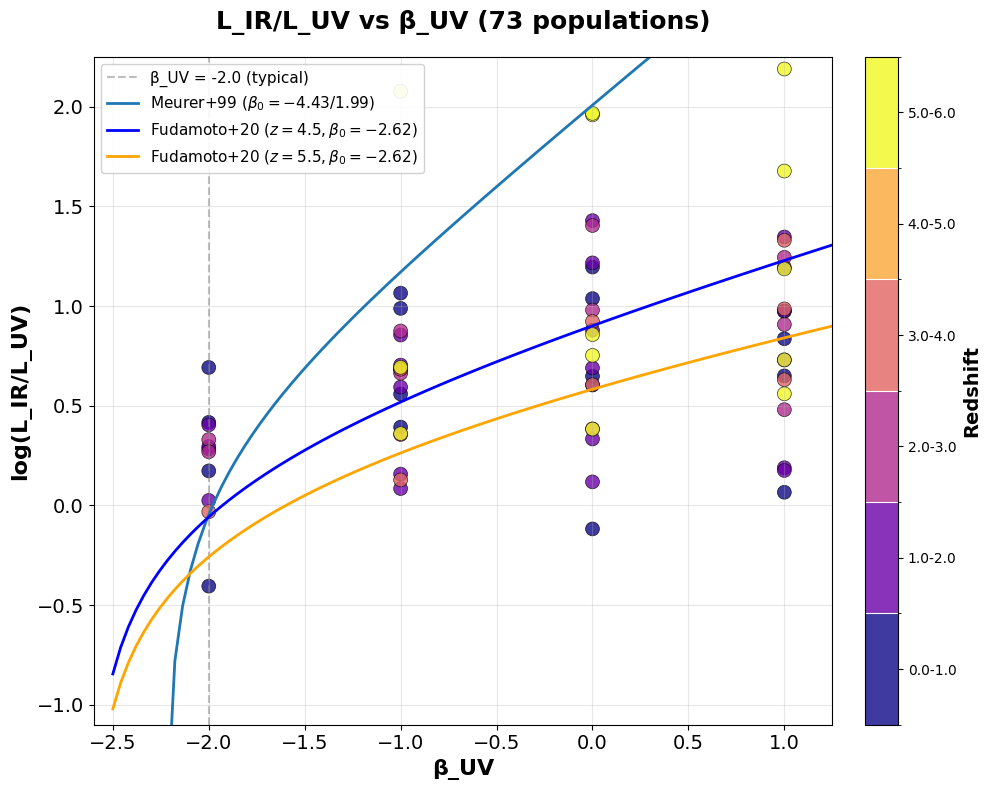

In [7]:
fig = create_lir_luv_beta_plot(
    wrapper, 
    color_by='redshift', 
    xlim=[-2.6,1.25],
    ylim=[-1.1,2.25],
)

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr', 'mcmc_used', 'mcmc_n_samples']
🔍 Using total_ir_luminosity_lsun for L_IR
✅ Found 73 detected populations
📊 Found 73 populations with β_UV and L_UV data
📊 Averaging over L_UV bins...
📊 Reduced to 30 averaged points
🎨 Using discrete colorbar with 6 bins

📈 Plot Summary:
   β_UV range: -2.00 to 1.00
   Redshift range: 0.26 to 7.50
   L_IR/L_UV range: -2.25e-01 to 1.43e+00
   Median L_IR/L_UV: 6.89e-01
   Colored by: redshift
   L_UV averaging: ON


/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_64343/732247877.py:259: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('plasma', n_colors)
/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_64343/732247877.py:375: RuntimeWarning: invalid value encountered in log10
  ax.plot(beta_model, np.log10(irx_meurer(beta_model)), label=r'Meurer+99 ($\beta_0 = -4.43/1.99$)', lw=2)


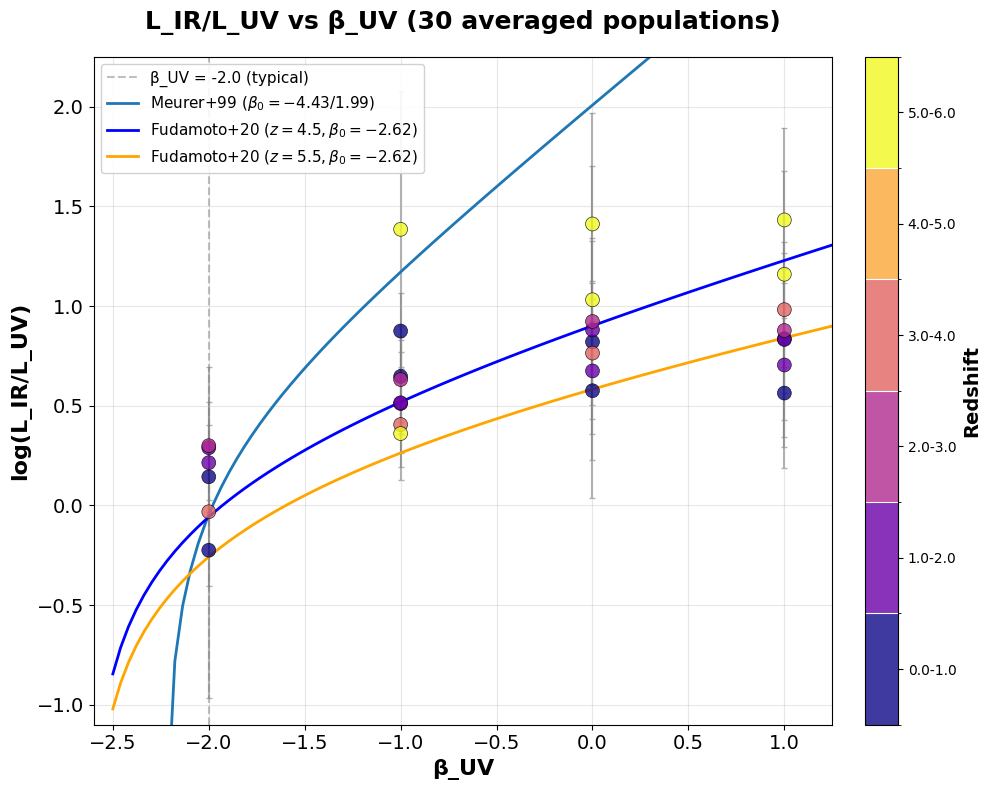

In [8]:
lir_luv_beta = create_lir_luv_beta_plot(
    wrapper, 
    xlim=[-2.6,1.25],
    ylim=[-1.1,2.25],
    average_luv=True,
)

In [18]:
def create_lir_luv_beta_plot_multipanel(wrapper, 
                                        show_errors=True,
                                        figsize=None,
                                        color_by='redshift',
                                        save_path=None, 
                                        xlim=None,
                                        ylim=None,
                                        max_panels=None,
                                        panel_arrangement='auto',
                                        add_irx_redshift_panel=True,
                                        average_luv_for_irx=True
                                      ):
    """
    Create multi-panel L_IR/L_UV vs β_UV plot from SimstackWrapper results
    One panel for each L_UV bin
    
    Parameters:
    -----------
    wrapper : SimstackWrapper
        Wrapper object with stacking_results and processed_results
    show_errors : bool
        Whether to show error bars
    figsize : tuple or None
        Figure size (width, height). If None, auto-calculated based on panels
    color_by : str
        What to color points by: 'redshift' (default) or 'stellar_mass'
    save_path : str or Path or None
        Path to save the figure
    xlim, ylim : tuple or None
        Axis limits
    max_panels : int or None
        Maximum number of panels to show
    add_irx_redshift_panel : bool
        If True and there's an empty panel, add IRX vs redshift plot
    average_luv_for_irx : bool
        If True, average over L_UV bins for the IRX vs redshift plot (default)
    """
    
    # Get results from wrapper
    if not hasattr(wrapper, 'stacking_results') or wrapper.stacking_results is None:
        print("❌ No stacking results found in wrapper")
        return None
        
    if not hasattr(wrapper, 'processed_results') or wrapper.processed_results is None:
        print("❌ No processed results found in wrapper")
        return None
    
    # Get summary dataframe
    try:
        if hasattr(wrapper.processed_results, 'get_population_summary'):
            summary_df = wrapper.processed_results.get_population_summary()
        else:
            summary_df = wrapper.population_manager.get_population_summary()
        
        print(f"📋 Available columns: {list(summary_df.columns)}")
        
    except Exception as e:
        print(f"❌ Could not get population summary: {e}")
        return None
    
    # Determine the correct population ID column name
    pop_id_col = None
    possible_id_cols = ['id_label', 'population_id', 'pop_id', 'label']
    
    for col in possible_id_cols:
        if col in summary_df.columns:
            pop_id_col = col
            break
    
    if pop_id_col is None:
        print(f"❌ Could not find population ID column. Available columns: {list(summary_df.columns)}")
        return None
    
    # Filter for detected populations only
    df = summary_df.copy()
    
    # Check if we have L_IR measurements
    lir_cols = [col for col in df.columns if 'ir_luminosity' in col.lower()]
    if not lir_cols:
        print("❌ No L_IR measurements found")
        return None
    
    lir_col = lir_cols[0]
    df = df[df[lir_col] > 0]
    print(f"🔍 Using {lir_col} for L_IR")
    
    if len(df) == 0:
        print("❌ No detected populations found")
        return None
    
    print(f"✅ Found {len(df)} detected populations")
    
    # Parse population information to extract β_UV, L_UV, etc.
    def parse_population_id(pop_id):
        """Extract binning information from population ID"""
        try:
            parts = pop_id.split('__')
            bin_info = {}
            
            for part in parts:
                if '_' in part:
                    elements = part.split('_')
                    if len(elements) >= 3:
                        try:
                            min_val = float(elements[-2])
                            max_val = float(elements[-1])
                            bin_name = '_'.join(elements[:-2])
                            bin_info[bin_name] = (min_val, max_val)
                        except ValueError:
                            continue
            
            return bin_info
        except Exception as e:
            print(f"⚠️  Could not parse population ID: {pop_id}")
            return {}
    
    # Parse all population IDs and organize by L_UV bin
    luv_bin_data = {}  # Dictionary to store data for each L_UV bin
    
    for idx, (_, pop) in enumerate(df.iterrows()):
        pop_id = pop[pop_id_col]
        bin_info = parse_population_id(pop_id)
        
        # Extract β_UV, L_UV, and other values from binning
        beta_uv = None
        l_uv_bin = None
        redshift = None
        stellar_mass = None
        
        for bin_name, (min_val, max_val) in bin_info.items():
            if 'beta' in bin_name.lower():
                beta_uv = (min_val + max_val) / 2
            elif 'l_uv' in bin_name.lower() or 'luv' in bin_name.lower():
                l_uv_bin = (min_val, max_val)  # Keep as tuple for grouping
            elif 'redshift' in bin_name.lower() or bin_name.lower() == 'z':
                redshift = (min_val + max_val) / 2
            elif 'mass' in bin_name.lower() and 'stellar' in bin_name.lower():
                stellar_mass = (min_val + max_val) / 2
        
        # Also try to get values from dataframe columns
        if redshift is None and 'median_redshift' in pop:
            redshift = pop['median_redshift']
        if stellar_mass is None and 'median_log_mass' in pop:
            stellar_mass = pop['median_log_mass']
        
        # Get L_IR
        l_ir = pop[lir_col]
        
        # Only include if we have the required values
        if beta_uv is not None and l_uv_bin is not None and l_ir > 0:
            # Use L_UV bin as key
            luv_key = f"{l_uv_bin[0]:.1f}-{l_uv_bin[1]:.1f}"
            
            if luv_key not in luv_bin_data:
                luv_bin_data[luv_key] = {
                    'beta_uv': [],
                    'l_uv_center': [],
                    'redshift': [],
                    'stellar_mass': [],
                    'l_ir_luv_ratio': [],
                    'l_uv_range': l_uv_bin
                }
            
            # Calculate L_IR/L_UV ratio
            l_uv_center = (l_uv_bin[0] + l_uv_bin[1]) / 2
            l_uv_linear = 10**l_uv_center
            l_ir_luv_ratio = np.log10(l_ir / l_uv_linear)
            
            luv_bin_data[luv_key]['beta_uv'].append(beta_uv)
            luv_bin_data[luv_key]['l_uv_center'].append(l_uv_center)
            luv_bin_data[luv_key]['redshift'].append(redshift if redshift is not None else np.nan)
            luv_bin_data[luv_key]['stellar_mass'].append(stellar_mass if stellar_mass is not None else np.nan)
            luv_bin_data[luv_key]['l_ir_luv_ratio'].append(l_ir_luv_ratio)
    
    if len(luv_bin_data) == 0:
        print("❌ No populations found with both β_UV and L_UV binning")
        return None
    
    # Sort L_UV bins by their range
    sorted_luv_keys = sorted(luv_bin_data.keys(), 
                            key=lambda x: luv_bin_data[x]['l_uv_range'][0])
    
    # Limit number of panels if requested
    if max_panels and len(sorted_luv_keys) > max_panels:
        print(f"⚠️ Limiting to {max_panels} panels (from {len(sorted_luv_keys)} L_UV bins)")
        sorted_luv_keys = sorted_luv_keys[:max_panels]
    
    n_panels = len(sorted_luv_keys)
    print(f"📊 Creating {n_panels} panels for L_UV bins")
    
    # Determine panel arrangement
    if 'x' in panel_arrangement and panel_arrangement not in ['auto']:
        # Parse specific arrangement like '2x3', '3x2', etc.
        try:
            parts = panel_arrangement.lower().split('x')
            if len(parts) == 2:
                nrows, ncols = int(parts[0]), int(parts[1])
                print(f"📐 Using specified arrangement: {nrows}×{ncols}")
            else:
                raise ValueError("Invalid format")
        except (ValueError, IndexError):
            print(f"⚠️  Invalid panel arrangement '{panel_arrangement}', using auto")
            panel_arrangement = 'auto'
    
    if panel_arrangement == 'horizontal':
        nrows, ncols = 1, n_panels
    elif panel_arrangement == 'vertical':
        nrows, ncols = n_panels, 1
    elif panel_arrangement == 'square':
        nrows = ncols = int(np.ceil(np.sqrt(n_panels)))
    elif 'x' not in panel_arrangement:  # auto or other
        if n_panels <= 3:
            nrows, ncols = 1, n_panels
        elif n_panels <= 6:
            nrows, ncols = 2, int(np.ceil(n_panels / 2))
        else:
            nrows = ncols = int(np.ceil(np.sqrt(n_panels)))
    
    # If using specific arrangement, warn if we have more panels than grid spaces
    if 'x' in panel_arrangement and panel_arrangement not in ['auto']:
        total_spaces = nrows * ncols
        if n_panels > total_spaces:
            print(f"⚠️  Warning: {n_panels} panels but only {total_spaces} spaces in {nrows}×{ncols} grid")
            print(f"   Some panels will be hidden. Consider using max_panels={total_spaces}")
        elif n_panels < total_spaces:
            print(f"ℹ️  Note: {n_panels} panels in {nrows}×{ncols} grid, {total_spaces - n_panels} empty spaces")
    
    # Calculate figure size
    if figsize is None:
        panel_width = 4
        panel_height = 3.5
        figsize = (ncols * panel_width, nrows * panel_height)
    
    # Check if we have space for IRX vs redshift panel
    total_spaces = nrows * ncols
    has_empty_space = n_panels < total_spaces and add_irx_redshift_panel
    
    if has_empty_space:
        print(f"📊 Adding IRX vs redshift panel in empty space")
        effective_panels = n_panels + 1  # Reserve one space for IRX plot
    else:
        effective_panels = n_panels
    
    print(f"📐 Panel arrangement: {nrows}×{ncols}, Figure size: {figsize}")
    print(f"📊 L_UV panels: {n_panels}, Total spaces: {total_spaces}")
    if has_empty_space:
        print(f"📈 IRX vs redshift panel: included")
    
    # Create the figure with individual axes (not shared for x-axis)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, 
                           sharey=True)  # Only share y-axis
    
    # Remove spacing between panels
    plt.subplots_adjust(hspace=0.02, wspace=0.02)
    
    # Handle single panel case
    if n_panels == 1:
        axes = np.array([axes])
    elif nrows == 1 or ncols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    # Set up colormap
    if color_by == 'stellar_mass':
        color_label = 'log M*/M☉'
        cmap = 'viridis'
    else:  # default to redshift
        color_label = 'Redshift'
        cmap = 'plasma'
    
    # Plot each L_UV bin in its own panel
    for panel_idx, luv_key in enumerate(sorted_luv_keys):
        if panel_idx >= len(axes):
            break
            
        ax = axes[panel_idx]
        data = luv_bin_data[luv_key]
        
        # Convert to arrays
        beta_uv_vals = np.array(data['beta_uv'])
        l_ir_luv_vals = np.array(data['l_ir_luv_ratio'])
        
        if color_by == 'stellar_mass':
            color_vals = np.array(data['stellar_mass'])
        else:
            color_vals = np.array(data['redshift'])
        
        if len(beta_uv_vals) == 0:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=12, alpha=0.5)
            ax.set_xlim(-3, 1)
            ax.set_ylim(-2, 2)
        else:
            # Check for valid color values
            valid_mask = np.isfinite(color_vals)
            
            if np.any(valid_mask):
                # Use colormap
                scatter = ax.scatter(beta_uv_vals, l_ir_luv_vals, 
                                    c=color_vals, cmap=cmap, s=80, alpha=0.8, 
                                    edgecolors='black', linewidth=0.5)
            else:
                # Use default color
                scatter = ax.scatter(beta_uv_vals, l_ir_luv_vals, 
                                    c='blue', s=80, alpha=0.8, 
                                    edgecolors='black', linewidth=0.5)
            
            # Add literature relations
            beta_model = np.linspace(-2.5, 1.5, 100)
            
            # Only add on first panel to avoid legend duplication
            if panel_idx == 0:
                ax.plot(beta_model, np.log10(irx_meurer(beta_model)), 
                       label='Meurer+99', lw=2, color='black', alpha=0.7)
                ax.plot(beta_model, np.log10(irx_fudamoto(beta_model, redshift=4.5)), 
                       label='Fudamoto+20 (z=4.5)', lw=2, color='blue', alpha=0.7)
                ax.plot(beta_model, np.log10(irx_fudamoto(beta_model, redshift=5.5)), 
                       label='Fudamoto+20 (z=5.5)', lw=2, color='orange', alpha=0.7)
                ax.legend(loc='lower right', fontsize=9, frameon=True, framealpha=0.8)
            else:
                ax.plot(beta_model, np.log10(irx_meurer(beta_model)), 
                       lw=2, color='black', alpha=0.7)
                ax.plot(beta_model, np.log10(irx_fudamoto(beta_model, redshift=4.5)), 
                       lw=2, color='blue', alpha=0.7)
                ax.plot(beta_model, np.log10(irx_fudamoto(beta_model, redshift=5.5)), 
                       lw=2, color='orange', alpha=0.7)
                    
        # Clean panel title in a text box (top left)
        l_uv_range = data['l_uv_range']
        textstr = f'log L_UV/L☉ = {l_uv_range[0]:.1f}–{l_uv_range[1]:.1f}'
        
        # Create text box properties
        props = dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=props)
        
        # Grid
        ax.grid(True, alpha=0.3)
        
        # Set limits
        if xlim is not None:
            ax.set_xlim(xlim)
        if ylim is not None:
            ax.set_ylim(ylim)
        
        # Labels only for edge panels to minimize clutter
        row = panel_idx // ncols
        col = panel_idx % ncols
        
        if row == nrows - 1:  # Bottom row
            ax.set_xlabel('β_UV', fontsize=12, fontweight='bold')
        if col == 0:  # Left column
            ax.set_ylabel('log(L_IR/L_UV)', fontsize=12, fontweight='bold')
        
        # Show tick marks on all panels, but only labels on edges
        ax.tick_params(axis='both', which='major', labelsize=10)
        
        if row != nrows - 1:  # Not bottom row - hide x labels but keep ticks
            ax.tick_params(axis='x', labelbottom=False)
        if col != 0:  # Not left column - hide y labels but keep ticks
            ax.tick_params(axis='y', labelleft=False)
    
    # Hide unused subplots, but reserve space for IRX plot if needed
    panels_to_hide_start = n_panels + (1 if has_empty_space else 0)
    for i in range(panels_to_hide_start, len(axes)):
        axes[i].set_visible(False)
    
    # Add IRX vs redshift panel if we have space
    if has_empty_space and n_panels < len(axes):
        irx_ax = axes[n_panels]  # Use the first empty panel
        
        # Prepare data for IRX vs redshift plot
        irx_redshift_data = []
        irx_beta_data = []
        irx_luv_data = []
        
        for luv_key in sorted_luv_keys:
            data = luv_bin_data[luv_key]
            if len(data['beta_uv']) > 0:
                for i in range(len(data['beta_uv'])):
                    irx_value = (data['l_ir_luv_ratio'][i])  # Convert log(L_IR/L_UV) to IRX
                    redshift = data['redshift'][i]
                    beta_uv = data['beta_uv'][i]
                    l_uv = data['l_uv_center'][i]
                    
                    if np.isfinite(redshift) and np.isfinite(irx_value) and np.isfinite(beta_uv):
                        irx_redshift_data.append((redshift, irx_value, beta_uv, l_uv))
        
        if len(irx_redshift_data) > 0:
            # Convert to arrays
            irx_data_array = np.array(irx_redshift_data)
            redshifts = irx_data_array[:, 0]
            irx_values = irx_data_array[:, 1]
            beta_values = irx_data_array[:, 2]
            luv_values = irx_data_array[:, 3]
            
            # Optional: Average over L_UV bins
            if average_luv_for_irx:
                # Group by redshift and beta_uv bins, average over L_UV
                unique_combinations = {}
                
                for i in range(len(redshifts)):
                    # Create key from redshift and beta_uv (rounded for grouping)
                    z_key = round(redshifts[i], 2)
                    beta_key = round(beta_values[i], 2)
                    key = (z_key, beta_key)
                    
                    if key not in unique_combinations:
                        unique_combinations[key] = {'redshift': [], 'irx': [], 'beta': []}
                    
                    unique_combinations[key]['redshift'].append(redshifts[i])
                    unique_combinations[key]['irx'].append(irx_values[i])
                    unique_combinations[key]['beta'].append(beta_values[i])
                
                # Average the grouped values
                redshifts_avg = []
                irx_avg = []
                beta_avg = []
                
                for key, values in unique_combinations.items():
                    redshifts_avg.append(np.mean(values['redshift']))
                    irx_avg.append(np.mean(values['irx']))
                    beta_avg.append(np.mean(values['beta']))
                
                redshifts = np.array(redshifts_avg)
                irx_values = np.array(irx_avg)
                beta_values = np.array(beta_avg)
                
                print(f"📊 IRX plot: averaged to {len(redshifts)} points")
            else:
                print(f"📊 IRX plot: {len(redshifts)} individual points")
            
            # Create IRX vs redshift plot colored by β_UV
            if len(redshifts) > 0:
                scatter_irx = irx_ax.scatter(redshifts, irx_values, 
                                           c=beta_values, cmap='coolwarm', s=80, alpha=0.8, 
                                           edgecolors='black', linewidth=0.5)
                
                
                '''# Set appropriate x-axis range for redshift
                if len(redshifts) > 0:
                    z_range = np.max(redshifts) - np.min(redshifts)
                    z_padding = z_range * 0.1 if z_range > 0 else 0.5
                    irx_ax.set_xlim(np.min(redshifts) - z_padding, 
                                   np.max(redshifts) + z_padding)
                else:
                    irx_ax.set_xlim(0, 6)  # Default redshift range
                
                irx_ax.set_yscale('log')
                irx_ax.set_ylim(0.1, 100)'''
                irx_ax.set_ylim(ylim)
                irx_ax.set_xlim(0, 6)
                
                # Add colorbar for β_UV on this panel
                cbar_irx = plt.colorbar(scatter_irx, ax=irx_ax, fraction=0.2, pad=0.03)
                cbar_irx.set_label('β_UV', fontsize=10)
                cbar_irx.ax.tick_params(labelsize=9)
                
                # Grid
                irx_ax.grid(True, alpha=0.3)
                
                # Add x-axis label and ticks to IRX panel
                irx_ax.set_xlabel('Redshift', fontsize=11, fontweight='bold')
                irx_ax.tick_params(axis='both', which='major', labelsize=10)
                
                # Y-axis label only if in left column
                row = n_panels // ncols
                col = n_panels % ncols
                
                if col == 0:  # Left column
                    irx_ax.set_ylabel('IRX = L_IR/L_UV', fontsize=12, fontweight='bold')
                else:
                    # Hide y-axis labels but keep ticks for non-left columns
                    irx_ax.tick_params(axis='y', labelleft=False)
                
                # Text box for panel identification
                avg_text = "L_UV averaged" if average_luv_for_irx else ""
                textstr = f'{avg_text}'
                props = dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.8, edgecolor='gray')
                irx_ax.text(0.05, 0.95, textstr, transform=irx_ax.transAxes, fontsize=10,
                           verticalalignment='top', bbox=props)
        else:
            # No data for IRX plot
            irx_ax.text(0.5, 0.5, 'No IRX Data', ha='center', va='center', 
                       transform=irx_ax.transAxes, fontsize=12, alpha=0.5)
            irx_ax.set_xlim(0, 6)
            irx_ax.set_ylim(0.1, 100)
    
    # Add a single colorbar for the entire figure - OUTSIDE on the right
    if color_by in ['redshift', 'stellar_mass'] and n_panels > 0:
        # Get data from all panels to determine colorbar range
        all_color_vals = []
        for luv_key in sorted_luv_keys:
            data = luv_bin_data[luv_key]
            if color_by == 'stellar_mass':
                color_vals = np.array(data['stellar_mass'])
            else:
                color_vals = np.array(data['redshift'])
            
            valid_vals = color_vals[np.isfinite(color_vals)]
            if len(valid_vals) > 0:
                all_color_vals.extend(valid_vals)
        
        if len(all_color_vals) > 0:
            # Create a mappable for the colorbar
            from matplotlib.cm import ScalarMappable
            from matplotlib.colors import Normalize
            
            norm = Normalize(vmin=np.min(all_color_vals), vmax=np.max(all_color_vals))
            sm = ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            
            # Adjust subplot layout to make room for colorbar on the right
            plt.subplots_adjust(right=0.85, left=0.08, bottom=0.08, top=0.92, hspace=0.02, wspace=0.02)
            
            # Add colorbar OUTSIDE the plot area on the right
            cbar_ax = fig.add_axes([0.87, 0.08, 0.02, 0.84])  # [left, bottom, width, height] - thinner and taller
            cbar = fig.colorbar(sm, cax=cbar_ax)
            cbar.set_label(color_label, fontsize=12, fontweight='bold')
            cbar.ax.tick_params(labelsize=10)
    else:
        # No colorbar, use more space for plots
        plt.subplots_adjust(right=0.95, left=0.08, bottom=0.08, top=0.92, hspace=0.02, wspace=0.02)
    
    # Overall title
    fig.suptitle(f'L_IR/L_UV vs β_UV by L_UV bin ({sum(len(data["beta_uv"]) for data in luv_bin_data.values())} populations)', 
                fontsize=14, fontweight='bold', y=0.96)
    
    # Layout is already adjusted above - no need for separate adjustment
    
    # Save figure if path provided
    if save_path is not None:
        try:
            from pathlib import Path
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            
            dpi = 300 if save_path.suffix.lower() in ['.png', '.jpg', '.jpeg'] else 150
            plt.savefig(save_path, dpi=dpi, bbox_inches='tight', 
                       facecolor='white', edgecolor='none')
            print(f"💾 Figure saved to: {save_path}")
            
        except Exception as e:
            print(f"⚠️  Could not save figure: {e}")
    
    # Print summary
    print(f"\n📈 Multi-Panel Plot Summary:")
    print(f"   Number of L_UV bins: {n_panels}")
    print(f"   Panel arrangement: {nrows}×{ncols}")
    print(f"   Total populations: {sum(len(data['beta_uv']) for data in luv_bin_data.values())}")
    for luv_key in sorted_luv_keys:
        data = luv_bin_data[luv_key]
        n_points = len(data['beta_uv'])
        if n_points > 0:
            beta_range = f"{np.min(data['beta_uv']):.2f} to {np.max(data['beta_uv']):.2f}"
            print(f"   L_UV {luv_key}: {n_points} points, β_UV range: {beta_range}")
    print(f"   Colored by: {color_by}")
    if has_empty_space:
        avg_note = " (L_UV averaged)" if average_luv_for_irx else " (individual points)"
        print(f"   IRX vs redshift panel: included{avg_note}")
    
    return fig

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr', 'mcmc_used', 'mcmc_n_samples']
🔍 Using total_ir_luminosity_lsun for L_IR
✅ Found 73 detected populations
📊 Creating 3 panels for L_UV bins
📐 Using specified arrangement: 2×2
ℹ️  Note: 3 panels in 2×2 grid, 1 empty spaces
📊 Adding IRX vs redshift panel in empty space
📐 Panel arrangement: 2×2, Figure size: (8, 7.0)
📊 L_UV panels: 3, Total spaces: 4
📈 IRX vs redshift panel: included
📊 IRX plot: averaged to 30 points

📈 Multi-Panel Plot Summary:
   Number of L_UV bins: 3
   Panel arrangement: 2×2
   Total populations: 73
   L_UV 9.0-10.0: 22 points, β_UV range: -2.00 to 1.00
   L_UV 10.0-11.0: 27 points, β_UV range: -2.00 t

/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_64343/3394107980.py:314: RuntimeWarning: invalid value encountered in log10
  ax.plot(beta_model, np.log10(irx_meurer(beta_model)),
/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_64343/3394107980.py:322: RuntimeWarning: invalid value encountered in log10
  ax.plot(beta_model, np.log10(irx_meurer(beta_model)),


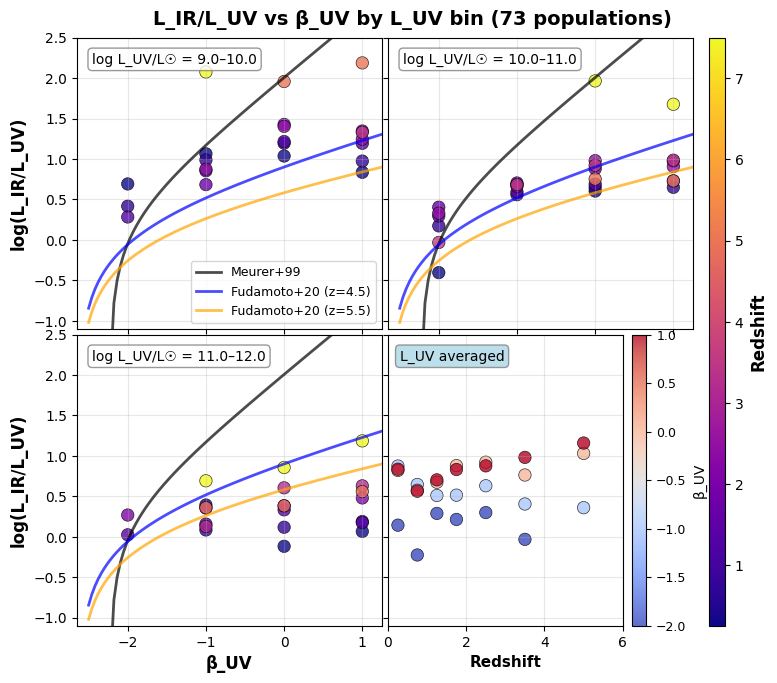

In [19]:
# Add IRX panel without L_UV averaging  
fig = create_lir_luv_beta_plot_multipanel(
    wrapper, 
    panel_arrangement='2x2',  # 9 spaces = plenty of room
    xlim=np.array([-2.65,1.25]),
    ylim=np.array([-1.1,2.5]),
    add_irx_redshift_panel=True,
    average_luv_for_irx=True,
    #save_path="/Users/mviero/Desktop/lir_luv_beta_multipanel.pdf"
)

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr', 'mcmc_used', 'mcmc_n_samples']
🔍 Using total_ir_luminosity_lsun for L_IR
✅ Found 73 detected populations
📊 Creating 3 panels for L_UV bins
📐 Using specified arrangement: 2×2
ℹ️  Note: 3 panels in 2×2 grid, 1 empty spaces
📐 Panel arrangement: 2×2, Figure size: (8, 7.0)
📊 L_UV panels: 3, Total spaces: 4


/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_64343/1054383329.py:314: RuntimeWarning: invalid value encountered in log10
  ax.plot(beta_model, np.log10(irx_meurer(beta_model)),
/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_64343/1054383329.py:322: RuntimeWarning: invalid value encountered in log10
  ax.plot(beta_model, np.log10(irx_meurer(beta_model)),


💾 Figure saved to: /Users/mviero/Desktop/lir_luv_beta_multipanel.pdf

📈 Multi-Panel Plot Summary:
   Number of L_UV bins: 3
   Panel arrangement: 2×2
   Total populations: 73
   L_UV 9.0-10.0: 22 points, β_UV range: -2.00 to 1.00
   L_UV 10.0-11.0: 27 points, β_UV range: -2.00 to 1.00
   L_UV 11.0-12.0: 24 points, β_UV range: -2.00 to 1.00
   Colored by: redshift


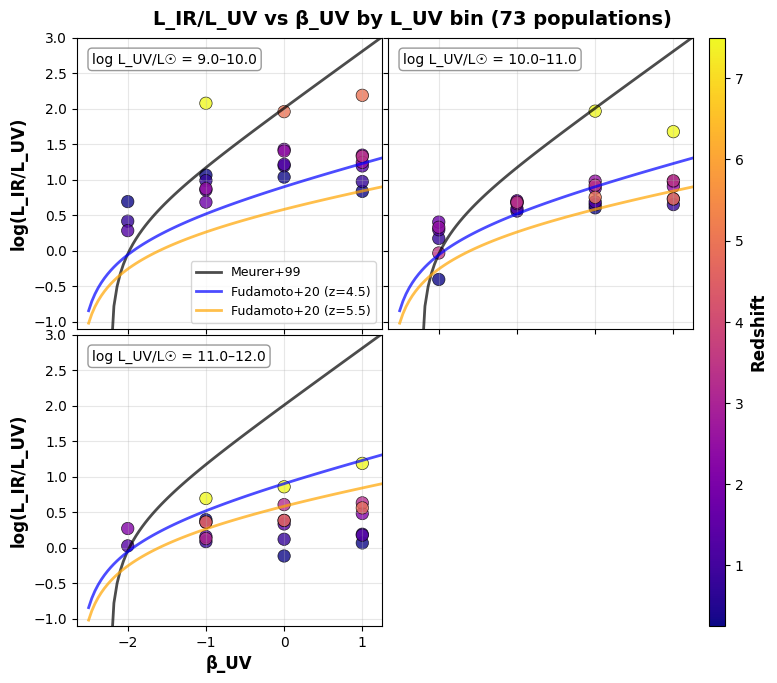

In [11]:
# Add IRX panel without L_UV averaging  
fig = create_lir_luv_beta_plot_multipanel(
    wrapper, 
    panel_arrangement='2x2',  # 9 spaces = plenty of room
    xlim=np.array([-2.65,1.25]),
    ylim=np.array([-1.1,3]),
    add_irx_redshift_panel=False,
    average_luv_for_irx=False,
    save_path="/Users/mviero/Desktop/lir_luv_beta_multipanel.pdf"
)

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr', 'mcmc_used', 'mcmc_n_samples']
🔍 Using total_ir_luminosity_lsun for L_IR
✅ Found 73 detected populations
📊 Creating 3 panels for L_UV bins
📐 Using specified arrangement: 2×2
ℹ️  Note: 3 panels in 2×2 grid, 1 empty spaces
📊 Adding IRX vs redshift panel in empty space
📐 Panel arrangement: 2×2, Figure size: (8, 7.0)
📊 L_UV panels: 3, Total spaces: 4
📈 IRX vs redshift panel: included
📊 IRX plot: averaged to 30 points

📈 Multi-Panel Plot Summary:
   Number of L_UV bins: 3
   Panel arrangement: 2×2
   Total populations: 73
   L_UV 9.0-10.0: 22 points, β_UV range: -2.00 to 1.00
   L_UV 10.0-11.0: 27 points, β_UV range: -2.00 t

/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_64343/1054383329.py:314: RuntimeWarning: invalid value encountered in log10
  ax.plot(beta_model, np.log10(irx_meurer(beta_model)),
/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_64343/1054383329.py:322: RuntimeWarning: invalid value encountered in log10
  ax.plot(beta_model, np.log10(irx_meurer(beta_model)),


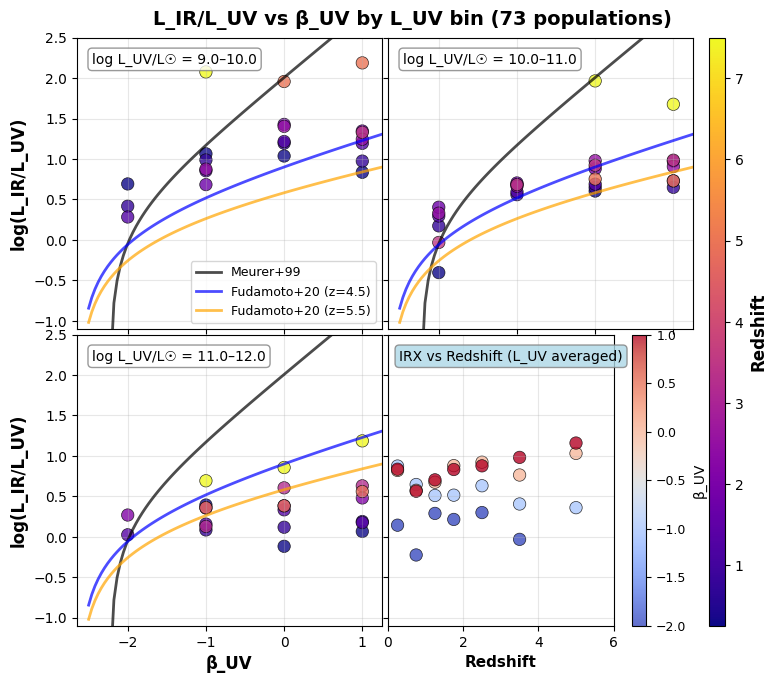

In [12]:
# Add IRX panel without L_UV averaging  
fig = create_lir_luv_beta_plot_multipanel(
    wrapper, 
    panel_arrangement='2x2',  # 9 spaces = plenty of room
    xlim=np.array([-2.65,1.25]),
    ylim=np.array([-1.1,2.5]),
    add_irx_redshift_panel=True,
    average_luv_for_irx=True,
    #save_path="/Users/mviero/Desktop/lir_luv_beta_multipanel.pdf"
)

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr', 'mcmc_used', 'mcmc_n_samples']
🔍 Using total_ir_luminosity_lsun for L_IR
✅ Found 73 detected populations
📊 Creating 3 panels for L_UV bins
📐 Using specified arrangement: 2×2
ℹ️  Note: 3 panels in 2×2 grid, 1 empty spaces
📊 Adding IRX vs redshift panel in empty space
📐 Panel arrangement: 2×2, Figure size: (8, 7.0)
📊 L_UV panels: 3, Total spaces: 4
📈 IRX vs redshift panel: included
📊 IRX plot: averaged to 30 points


/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_64343/1054383329.py:314: RuntimeWarning: invalid value encountered in log10
  ax.plot(beta_model, np.log10(irx_meurer(beta_model)),
/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_64343/1054383329.py:322: RuntimeWarning: invalid value encountered in log10
  ax.plot(beta_model, np.log10(irx_meurer(beta_model)),


💾 Figure saved to: /Users/mviero/Desktop/lir_luv_beta_multipanel.pdf

📈 Multi-Panel Plot Summary:
   Number of L_UV bins: 3
   Panel arrangement: 2×2
   Total populations: 73
   L_UV 9.0-10.0: 22 points, β_UV range: -2.00 to 1.00
   L_UV 10.0-11.0: 27 points, β_UV range: -2.00 to 1.00
   L_UV 11.0-12.0: 24 points, β_UV range: -2.00 to 1.00
   Colored by: redshift
   IRX vs redshift panel: included (L_UV averaged)


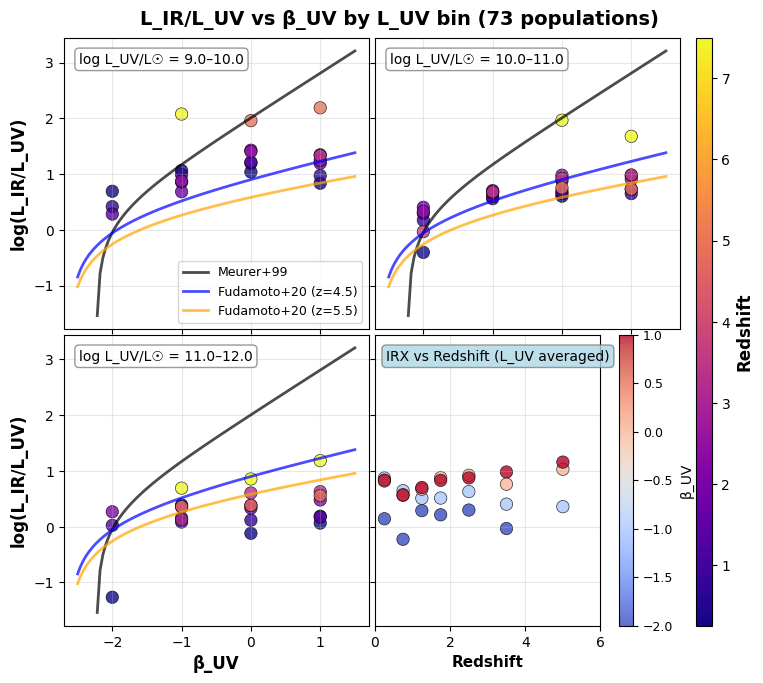

In [13]:
# Create multi-panel plot
fig = create_lir_luv_beta_plot_multipanel(
    wrapper, 
    color_by='redshift',
    panel_arrangement='2x2',
    max_panels=4,  # Limit to fit 2x2
    save_path="/Users/mviero/Desktop/lir_luv_beta_multipanel.pdf"
)